# Expense Forecasting — Time-Series Regression Model

**Goal:** Predict future daily household expenses based on historical spending patterns.

**Dataset:** `data/Daily Household Transactions.csv` (~2,463 rows, Sep 2018 onward)

**Cleaning decisions:**
- **Drop `Cash` mode** — real bank statements do not tag transactions as cash.
- Keep `Saving Bank account 1`, `Credit Card`, `Debit Card` only.
- Keep only `Expense` type rows for spending prediction.
- Drop internal transfers and income rows from the target.

**Output:** `models/expense_forecaster.pkl`

## 0. Install Dependencies

In [ ]:
# Run once if packages are missing
# !pip install pandas numpy scikit-learn matplotlib seaborn joblib xgboost

## 1. Imports & Configuration

In [75]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import joblib

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score
)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

RANDOM_STATE = 42
DATA_DIR  = 'data'
MODEL_DIR = 'models'
os.makedirs(MODEL_DIR, exist_ok=True)

print('All imports loaded successfully.')

All imports loaded successfully.


## 2. Load Data

In [76]:
raw = pd.read_csv(
    os.path.join(DATA_DIR, 'Daily Household Transactions.csv'),
    on_bad_lines='skip'   # handles rows where Note field contains unquoted commas
)

print(f'Raw shape : {raw.shape}')
print(f'Columns   : {raw.columns.tolist()}')
raw.head(8)

Raw shape : (2461, 8)
Columns   : ['Date', 'Mode', 'Category', 'Subcategory', 'Note', 'Amount', 'Income/Expense', 'Currency']


,Date,Mode,Category,Subcategory,Note,Amount,Income/Expense,Currency
0,20/09/2018 12:04:08,Cash,Transportation,Train,2 Place 5 to Place 0,30.0,Expense,INR
1,20/09/2018 12:03:15,Cash,Food,snacks,Idli medu Vada mix 2 plates,60.0,Expense,INR
2,19/09/2018,Saving Bank account 1,subscription,Netflix,1 month subscription,199.0,Expense,INR
3,17/09/2018 23:41:17,Saving Bank account 1,subscription,Mobile Service Provider,Data booster pack,19.0,Expense,INR
4,16/09/2018 17:15:08,Cash,Festivals,Ganesh Pujan,Ganesh idol,251.0,Expense,INR
5,15/09/2018 06:34:17,Credit Card,subscription,Tata Sky,Permanent Residence - Tata Play recharge,200.0,Expense,INR
6,14/09/2018 05:39:17,Cash,Transportation,auto,Place 2 station to Permanent Residence,50.0,Expense,INR
7,13/09/2018 21:35:15,Saving Bank account 1,Transportation,Train,2 Place 0 to Place 3,40.0,Expense,INR


## 3. Exploratory Data Analysis

In [77]:
print('Null counts per column:')
print(raw.isnull().sum())
print('\nValue counts — Mode:')
print(raw['Mode'].value_counts())
print('\nValue counts — Income/Expense:')
print(raw['Income/Expense'].value_counts())

Null counts per column:
Date                0
Mode                0
Category            0
Subcategory       635
Note              521
Amount              0
Income/Expense      0
Currency            0
dtype: int64

Value counts — Mode:
Mode
Saving Bank account 1    1223
Cash                     1046
Credit Card               162
Equity Mutual Fund B       11
Share Market Trading        5
Saving Bank account 2       5
Recurring Deposit           3
Debit Card                  2
Equity Mutual Fund C        1
Equity Mutual Fund A        1
Equity Mutual Fund D        1
Fixed Deposit               1
Name: count, dtype: int64

Value counts — Income/Expense:
Income/Expense
Expense         2176
Transfer-Out     160
Income           125
Name: count, dtype: int64


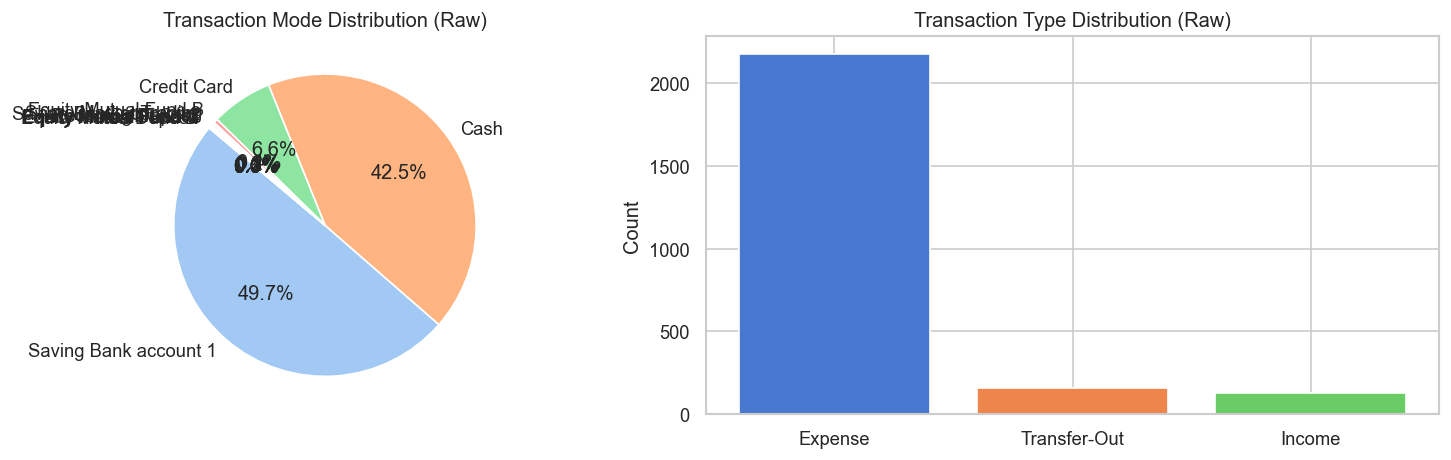

In [78]:
# ── Mode share before cleaning ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

mode_counts = raw['Mode'].value_counts()
axes[0].pie(mode_counts.values, labels=mode_counts.index,
            autopct='%1.1f%%', startangle=140,
            colors=sns.color_palette('pastel', len(mode_counts)))
axes[0].set_title('Transaction Mode Distribution (Raw)')

type_counts = raw['Income/Expense'].value_counts()
axes[1].bar(type_counts.index, type_counts.values,
            color=sns.color_palette('muted', len(type_counts)))
axes[1].set_title('Transaction Type Distribution (Raw)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

## 4. Data Cleaning

**Key cleaning rules:**

1. **Remap `Cash` mode instead of dropping it** so we keep full monthly coverage.
   - Cash + Expense  -> `ATM Withdrawal`
   - Cash + Income   -> `Net Banking IMPS/RTGS`
2. Keep valid banking modes only.
3. Keep both `Expense` and `Income` rows so we can model cash flow, not just spend.
4. Parse date, fix amount, and keep positive values.
5. Remove extreme transaction outliers (1%-99%).

In [79]:
df = raw.copy()

# ── Step 1: Remap Cash → bank-equivalent modes ───────────────────────────────
cash_mask    = df['Mode'].str.strip().str.lower() == 'cash'
expense_mask = df['Income/Expense'].str.strip() == 'Expense'

df.loc[cash_mask &  expense_mask, 'Mode'] = 'ATM Withdrawal'
df.loc[cash_mask & ~expense_mask, 'Mode'] = 'Net Banking IMPS/RTGS'

print(f'Cash rows remapped: {cash_mask.sum()}')
print('  Expense → ATM Withdrawal      :', (cash_mask & expense_mask).sum())
print('  Income  → Net Banking IMPS/RTGS:', (cash_mask & ~expense_mask).sum())

# ── Step 2: Keep all valid payment modes (now includes ATM / Net Banking) ────
valid_modes = df['Mode'].str.contains(
    r'Saving Bank|Credit Card|Debit Card|ATM|Net Banking',
    case=False, na=False
)
before = len(df)
df = df[valid_modes]
print(f'\nRows after keeping valid modes: {len(df)}  (dropped {before - len(df)})')
print('Mode breakdown:')
print(df['Mode'].value_counts().to_string())

Cash rows remapped: 1046
  Expense → ATM Withdrawal      : 1039
  Income  → Net Banking IMPS/RTGS: 7

Rows after keeping valid modes: 2438  (dropped 23)
Mode breakdown:
Mode
Saving Bank account 1    1223
ATM Withdrawal           1039
Credit Card               162
Net Banking IMPS/RTGS       7
Saving Bank account 2       5
Debit Card                  2


In [80]:
# ── Step 3: Keep Expense + Income rows ─────────────────────────────────────
before = len(df)
df = df[df['Income/Expense'].str.strip().isin(['Expense', 'Income'])]
print(f'Rows after keeping Expense + Income: {len(df)}  (dropped {before - len(df)})')
print('Type breakdown:')
print(df['Income/Expense'].value_counts().to_string())

Rows after keeping Expense + Income: 2295  (dropped 143)
Type breakdown:
Income/Expense
Expense    2176
Income      119


In [81]:
# ── Step 4: Parse Date ───────────────────────────────────────────────────────
# Mixed formats: 'DD/MM/YYYY HH:MM:SS', 'DD/MM/YYYY', 'D/M/YYYY'
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')

null_dates = df['Date'].isna().sum()
print(f'Unparseable date rows: {null_dates}')
df.dropna(subset=['Date'], inplace=True)

# Normalize to date only (remove time component)
df['Date'] = df['Date'].dt.normalize()

print(f'Date range: {df["Date"].min().date()} → {df["Date"].max().date()}')

Unparseable date rows: 1007
Date range: 2015-01-13 → 2018-09-20


In [82]:
# ── Step 5: Fix Amount column ────────────────────────────────────────────────
df['Amount'] = pd.to_numeric(df['Amount'], errors='coerce')

null_amounts = df['Amount'].isna().sum()
print(f'Non-numeric Amount rows: {null_amounts}')
df.dropna(subset=['Amount'], inplace=True)

# Only keep positive amounts (expense must be > 0)
df = df[df['Amount'] > 0]

print(f'Amount stats:\n{df["Amount"].describe().round(2)}')

Non-numeric Amount rows: 0
Amount stats:
count     1288.00
mean      2542.33
std      10887.16
min          2.00
25%         30.00
50%         72.00
75%        287.75
max      77335.00
Name: Amount, dtype: float64


In [83]:
# ── Step 6: Outlier removal (IQR method on Amount) ───────────────────────────
Q1, Q3 = df['Amount'].quantile(0.01), df['Amount'].quantile(0.99)
before = len(df)
df = df[(df['Amount'] >= Q1) & (df['Amount'] <= Q3)]
print(f'Rows after 1%-99% IQR clipping: {len(df)}  (removed {before - len(df)})')
print(f'Remaining shape: {df.shape}')

Rows after 1%-99% IQR clipping: 1273  (removed 15)
Remaining shape: (1273, 8)


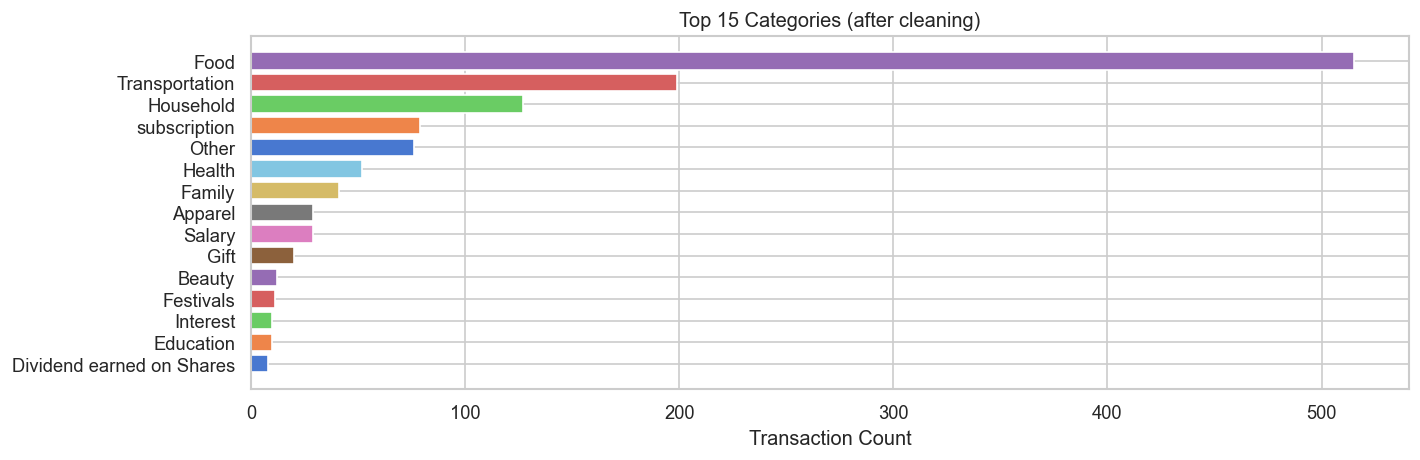

In [84]:
# ── Category distribution after cleaning ────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 4))
cat_counts = df['Category'].value_counts().head(15)
ax.barh(cat_counts.index[::-1], cat_counts.values[::-1],
        color=sns.color_palette('muted', len(cat_counts)))
ax.set_title('Top 15 Categories (after cleaning)')
ax.set_xlabel('Transaction Count')
plt.tight_layout()
plt.show()

## 5. Build Monthly Cash Flow Table

Now we aggregate both `Expense` and `Income` per month, then build:
- `Expense_Amount`
- `Income_Amount`
- `Net_Cash_Flow = Income_Amount - Expense_Amount`

We keep the same robust cleaning rules: sparse-month filter, monthly cap, and smoothing.

In [85]:
df['YearMonth'] = df['Date'].dt.to_period('M')

monthly = (
    df.groupby(['YearMonth', 'Income/Expense'])['Amount']
      .sum()
      .unstack(fill_value=0)
      .reset_index()
)

# Ensure both columns exist
if 'Expense' not in monthly.columns:
    monthly['Expense'] = 0
if 'Income' not in monthly.columns:
    monthly['Income'] = 0

monthly = monthly.rename(columns={'Expense':'Expense_Amount', 'Income':'Income_Amount'})

# Month-level transaction count for sparse filtering
tx_count = df.groupby('YearMonth')['Amount'].count().rename('tx_count').reset_index()
monthly = monthly.merge(tx_count, on='YearMonth', how='left')

before = len(monthly)
monthly = monthly[monthly['tx_count'] >= 5].sort_values('YearMonth').reset_index(drop=True)
print(f'Sparse months removed: {before - len(monthly)}')

# Cap monthly outliers separately for expense and income
exp_cap = monthly['Expense_Amount'].quantile(0.95)
inc_cap = monthly['Income_Amount'].quantile(0.95)
monthly['Expense_Amount'] = monthly['Expense_Amount'].clip(upper=exp_cap)
monthly['Income_Amount'] = monthly['Income_Amount'].clip(upper=inc_cap)

monthly['Net_Cash_Flow'] = monthly['Income_Amount'] - monthly['Expense_Amount']

# Smooth each target
SMOOTH_WINDOW = 10
monthly['Expense_Smoothed'] = monthly['Expense_Amount'].rolling(window=SMOOTH_WINDOW, min_periods=1).mean()
monthly['Income_Smoothed'] = monthly['Income_Amount'].rolling(window=SMOOTH_WINDOW, min_periods=1).mean()
monthly['Net_Smoothed'] = monthly['Net_Cash_Flow'].rolling(window=SMOOTH_WINDOW, min_periods=1).mean()

print(monthly[['YearMonth','tx_count','Expense_Amount','Income_Amount','Net_Cash_Flow']].to_string(index=False))

Sparse months removed: 2
YearMonth  tx_count  Expense_Amount  Income_Amount  Net_Cash_Flow
  2015-01        39         4434.00           0.00       -4434.00
  2015-02        31         6710.00       49806.00       43096.00
  2015-03        22         6509.80           0.00       -6509.80
  2015-04        12         3791.00       49306.00       45515.00
  2015-05        11        21076.00       47859.00       26783.00
  2015-08         7        15507.00       49806.00       34299.00
  2015-09         8         3198.00       49806.00       46608.00
  2015-10        22         8768.00       49806.00       41038.00
  2015-11        10          989.00       51306.00       50317.00
  2015-12        12         4356.00           0.00       -4356.00
  2016-01         5        10368.00       79252.50       68884.50
  2016-02        16        11610.00       49806.00       38196.00
  2016-03         8         1050.00           0.00       -1050.00
  2016-04         7         1279.00       51562.45 

Task was destroyed but it is pending!
task: <Task pending name='Task-363' coro=<_async_in_context.<locals>.run_in_context() done, defined at /Users/shreyas/Documents/8th_project/finance_advisor_v3/.venv/lib/python3.14/site-packages/ipykernel/utils.py:57> wait_for=<Task finished name='Task-364' coro=<Kernel.shell_main() done, defined at /Users/shreyas/Documents/8th_project/finance_advisor_v3/.venv/lib/python3.14/site-packages/ipykernel/kernelbase.py:597> exception=KeyError('f53a036e-b731-49b7-a320-9e1dffcfaa82')> cb=[ZMQStream._run_callback.<locals>._log_error() at /Users/shreyas/Documents/8th_project/finance_advisor_v3/.venv/lib/python3.14/site-packages/zmq/eventloop/zmqstream.py:563]>
Task exception was never retrieved
future: <Task finished name='Task-364' coro=<Kernel.shell_main() done, defined at /Users/shreyas/Documents/8th_project/finance_advisor_v3/.venv/lib/python3.14/site-packages/ipykernel/kernelbase.py:597> exception=KeyError('f53a036e-b731-49b7-a320-9e1dffcfaa82')>
Tracebac

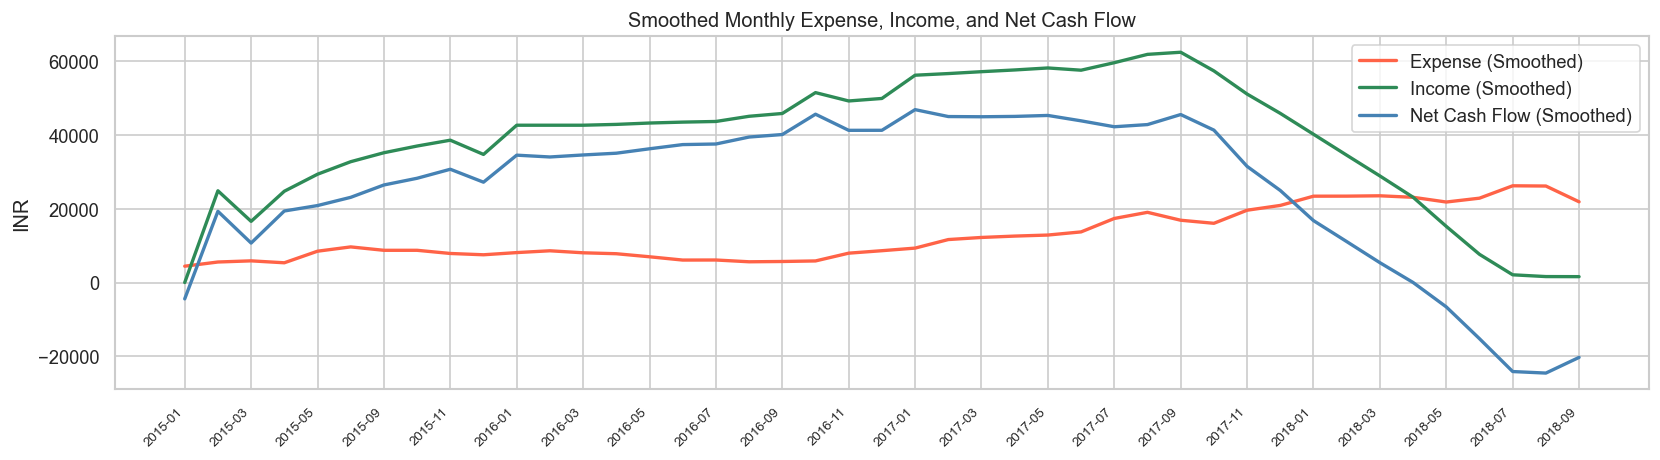

In [86]:
# Quick trend view
fig, ax = plt.subplots(1, 1, figsize=(14, 4))
x = range(len(monthly))
labels = monthly['YearMonth'].astype(str).tolist()

ax.plot(x, monthly['Expense_Smoothed'], label='Expense (Smoothed)', color='tomato', linewidth=2)
ax.plot(x, monthly['Income_Smoothed'], label='Income (Smoothed)', color='seagreen', linewidth=2)
ax.plot(x, monthly['Net_Smoothed'], label='Net Cash Flow (Smoothed)', color='steelblue', linewidth=2)

ax.set_xticks(list(x)[::2])
ax.set_xticklabels(labels[::2], rotation=45, ha='right', fontsize=8)
ax.set_title('Smoothed Monthly Expense, Income, and Net Cash Flow')
ax.set_ylabel('INR')
ax.legend()
plt.tight_layout()
plt.show()

## 6. Shared Feature Engineering

We use one shared feature set for all three targets.
Targets are modeled separately so each can learn its own dynamics.

In [87]:
N_LAGS = 5
monthly['time_step'] = range(len(monthly))
monthly['month_num'] = monthly['YearMonth'].dt.month
monthly['month_sin'] = np.sin(2 * np.pi * monthly['month_num'] / 12)
monthly['month_cos'] = np.cos(2 * np.pi * monthly['month_num'] / 12)

for lag in range(1, N_LAGS + 1):
    monthly[f'exp_lag_{lag}'] = monthly['Expense_Smoothed'].shift(lag)
    monthly[f'inc_lag_{lag}'] = monthly['Income_Smoothed'].shift(lag)
    monthly[f'net_lag_{lag}'] = monthly['Net_Smoothed'].shift(lag)

base_cols = ['time_step', 'month_sin', 'month_cos']
exp_cols = base_cols + [f'exp_lag_{i}' for i in range(1, N_LAGS+1)]
inc_cols = base_cols + [f'inc_lag_{i}' for i in range(1, N_LAGS+1)]
net_cols = base_cols + [f'net_lag_{i}' for i in range(1, N_LAGS+1)]

feat_exp = monthly[['YearMonth','Expense_Smoothed'] + exp_cols].dropna().reset_index(drop=True)
feat_inc = monthly[['YearMonth','Income_Smoothed'] + inc_cols].dropna().reset_index(drop=True)
feat_net = monthly[['YearMonth','Net_Smoothed'] + net_cols].dropna().reset_index(drop=True)

print(f'Expense rows: {len(feat_exp)}')
print(f'Income rows : {len(feat_inc)}')
print(f'Net rows    : {len(feat_net)}')

Expense rows: 38
Income rows : 38
Net rows    : 38


## 7. Walk-Forward Training Function

In [2]:
def walk_forward_ridge(feat_df, target_col, feature_cols, min_train=10, alphas=None):
    if alphas is None:
        alphas = [0.1, 0.2, 0.3, 0.5, 0.7, 1.0, 2.0, 5.0]

    X = feat_df[feature_cols].values
    y = feat_df[target_col].values
    months = feat_df['YearMonth'].astype(str).values

    alpha_scores = {}
    for a in alphas:
        p, t = [], []
        for i in range(min_train, len(X)):
            m = Pipeline([('scaler', StandardScaler()), ('ridge', Ridge(alpha=a))])
            m.fit(X[:i], y[:i])
            p.append(m.predict(X[i:i+1])[0])
            t.append(y[i])
        alpha_scores[a] = r2_score(t, p) if len(t) > 1 else -999

    best_alpha = max(alpha_scores, key=alpha_scores.get)

    preds, true, out_months = [], [], []
    for i in range(min_train, len(X)):
        m = Pipeline([('scaler', StandardScaler()), ('ridge', Ridge(alpha=best_alpha))])
        m.fit(X[:i], y[:i])
        preds.append(m.predict(X[i:i+1])[0])
        true.append(y[i])
        out_months.append(months[i])

    preds = np.array(preds)
    true = np.array(true)

    metrics = {
        'best_alpha': best_alpha,
        'r2': r2_score(true, preds),
        'rmse': np.sqrt(mean_squared_error(true, preds)),
        'mae': mean_absolute_error(true, preds),
        'n_preds': len(preds),
        'alpha_scores': alpha_scores
    }

    final_model = Pipeline([('scaler', StandardScaler()), ('ridge', Ridge(alpha=best_alpha))])
    final_model.fit(X, y)

    return final_model, metrics, out_months, true, preds


## 8. Train Expense, Income, and Net Models

In [89]:
expense_model, expense_metrics, exp_months, exp_true, exp_pred = walk_forward_ridge(
    feat_exp, 'Expense_Smoothed', exp_cols
)
income_model, income_metrics, inc_months, inc_true, inc_pred = walk_forward_ridge(
    feat_inc, 'Income_Smoothed', inc_cols
)
net_model, net_metrics, net_months, net_true, net_pred = walk_forward_ridge(
    feat_net, 'Net_Smoothed', net_cols
)

metrics_df = pd.DataFrame([
    {'Target':'Expense_Smoothed', **{k:v for k,v in expense_metrics.items() if k in ['best_alpha','r2','rmse','mae','n_preds']}},
    {'Target':'Income_Smoothed',  **{k:v for k,v in income_metrics.items() if k in ['best_alpha','r2','rmse','mae','n_preds']}},
    {'Target':'Net_Smoothed',     **{k:v for k,v in net_metrics.items() if k in ['best_alpha','r2','rmse','mae','n_preds']}},
])
print(metrics_df.to_string(index=False))

          Target  best_alpha       r2        rmse         mae  n_preds
Expense_Smoothed         0.3 0.911870 2043.099214 1666.178959       28
 Income_Smoothed         0.2 0.948757 4371.664513 2981.322046       28
    Net_Smoothed         0.1 0.949409 5429.275619 3910.637540       28


## 9. Plot Results

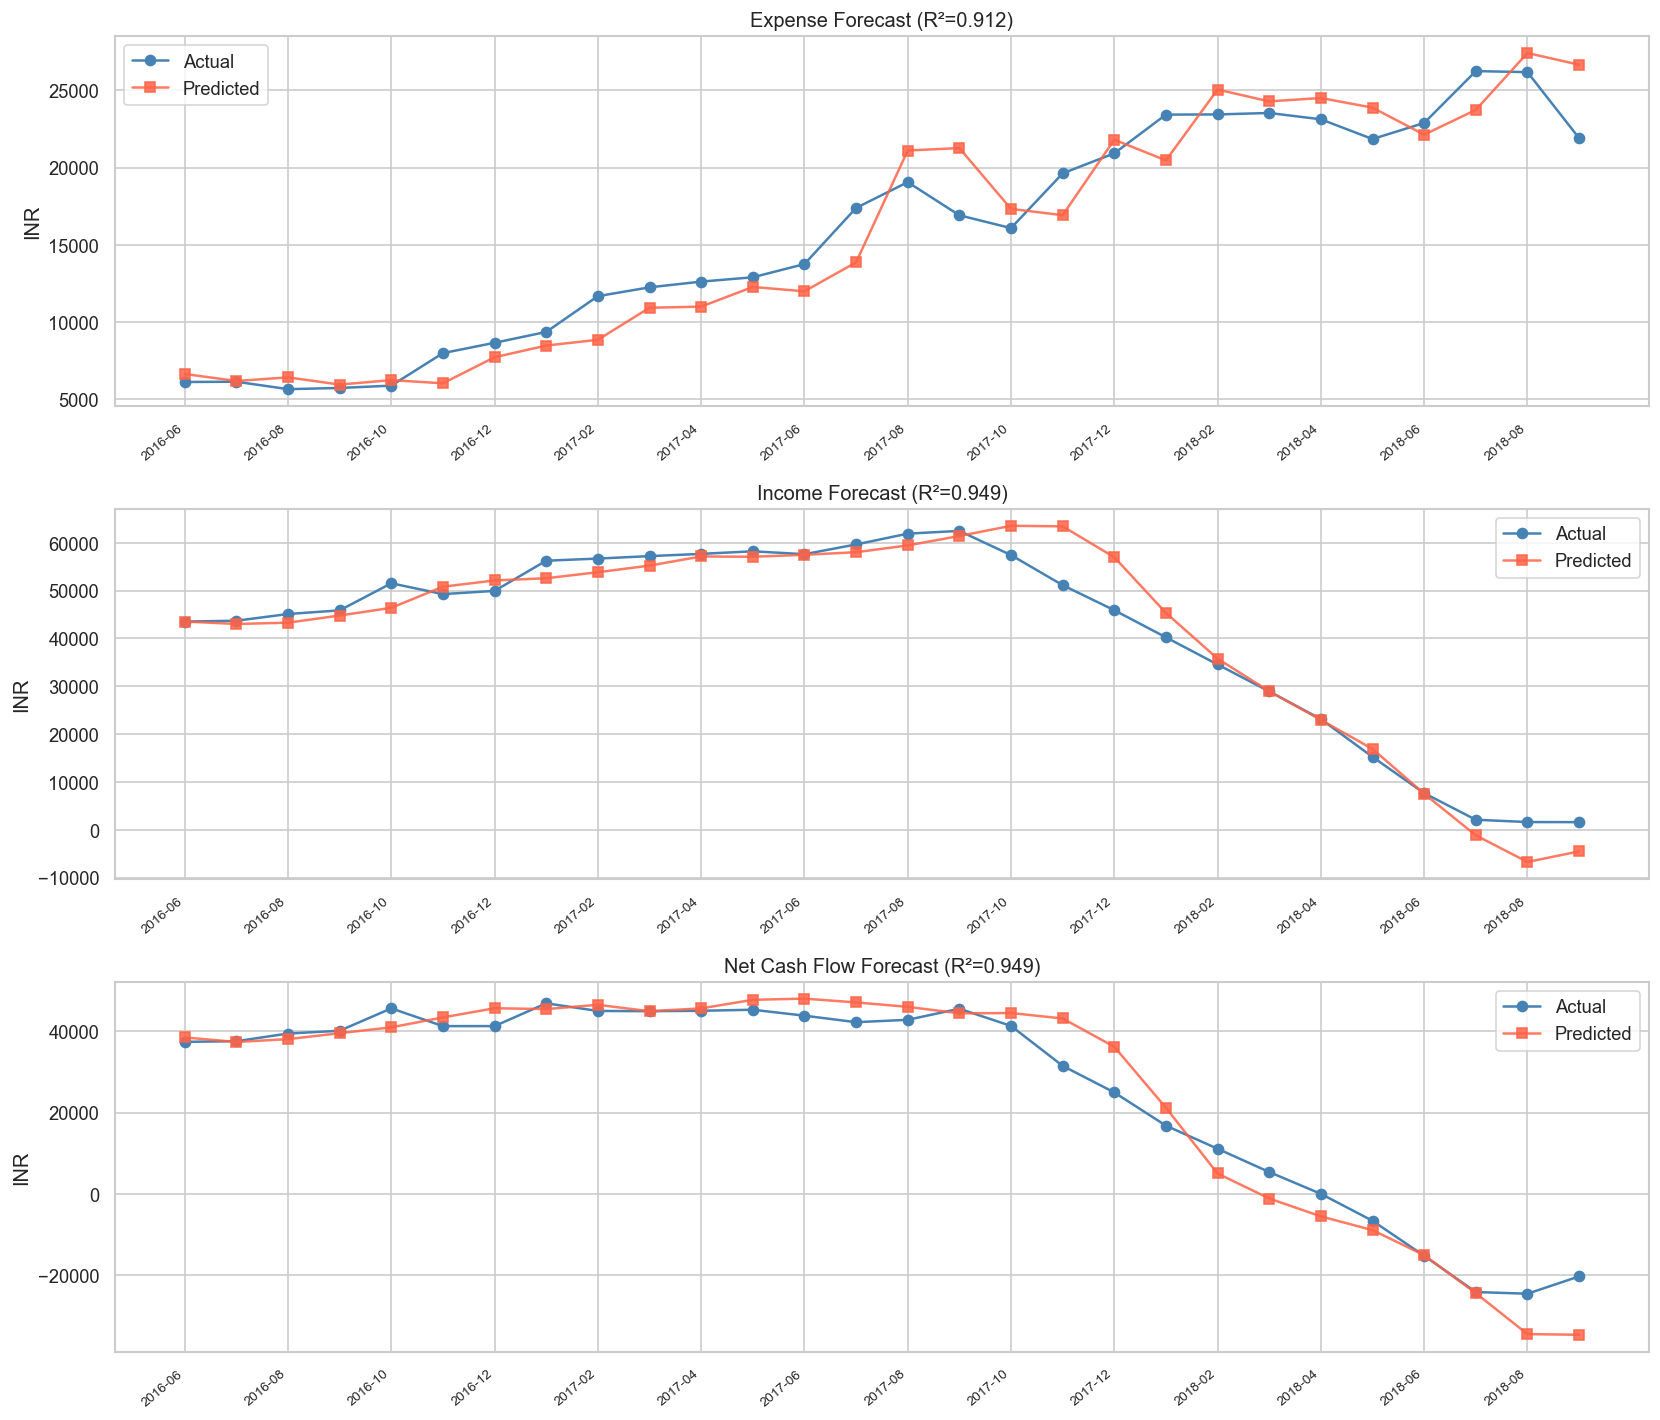

In [90]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

for ax, months, true, pred, title in [
    (axes[0], exp_months, exp_true, exp_pred, f'Expense Forecast (R²={expense_metrics["r2"]:.3f})'),
    (axes[1], inc_months, inc_true, inc_pred, f'Income Forecast (R²={income_metrics["r2"]:.3f})'),
    (axes[2], net_months, net_true, net_pred, f'Net Cash Flow Forecast (R²={net_metrics["r2"]:.3f})'),
]:
    x = range(len(months))
    ax.plot(x, true, color='steelblue', marker='o', label='Actual')
    ax.plot(x, pred, color='tomato', marker='s', alpha=0.85, label='Predicted')
    ax.set_xticks(list(x)[::2])
    ax.set_xticklabels(months[::2], rotation=40, ha='right', fontsize=8)
    ax.set_title(title)
    ax.set_ylabel('INR')
    ax.legend()

plt.tight_layout()
plt.show()

## 10. Save Models

In [91]:
model_payload = {
    'expense_model': expense_model,
    'income_model': income_model,
    'net_model': net_model,
    'smooth_window': SMOOTH_WINDOW,
    'n_lags': N_LAGS,
    'features': {
        'expense': exp_cols,
        'income': inc_cols,
        'net': net_cols
    },
    'metrics': {
        'expense': expense_metrics,
        'income': income_metrics,
        'net': net_metrics
    }
}

model_path = os.path.join(MODEL_DIR, 'cashflow_forecasters.pkl')
joblib.dump(model_payload, model_path)
print(f'Model payload saved -> {model_path}')

Model payload saved -> models/cashflow_forecasters.pkl


In [92]:
loaded = joblib.load(model_path)
print('Saved keys:', list(loaded.keys()))
print('Net model R²:', loaded['metrics']['net']['r2'])

Saved keys: ['expense_model', 'income_model', 'net_model', 'smooth_window', 'n_lags', 'features', 'metrics']
Net model R²: 0.9494087094377613


## Summary

This notebook now forecasts 3 targets:
- Expense
- Income
- Net cash flow (`Income - Expense`)

Cash is not dropped. It is mapped to banking-equivalent transaction modes and retained.

Saved output: `models/cashflow_forecasters.pkl`